In [1]:
#imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error , mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder

In [2]:
# using linear regression 
#checking the data 
df= pd.read_csv("CO2_emission.csv")
df.describe
print(df.index)
print("All columns are")
ai=0
for i in df:
    print(ai,i)
    ai+=1

RangeIndex(start=0, stop=935, step=1)
All columns are
0 Model_Year
1 Make
2 Model
3 Vehicle_Class
4 Engine_Size
5 Cylinders
6 Transmission
7 Fuel_Consumption_in_City(L/100 km)
8 Fuel_Consumption_in_City_Hwy(L/100 km)
9 Fuel_Consumption_comb(L/100km)
10 CO2_Emissions
11 Smog_Level


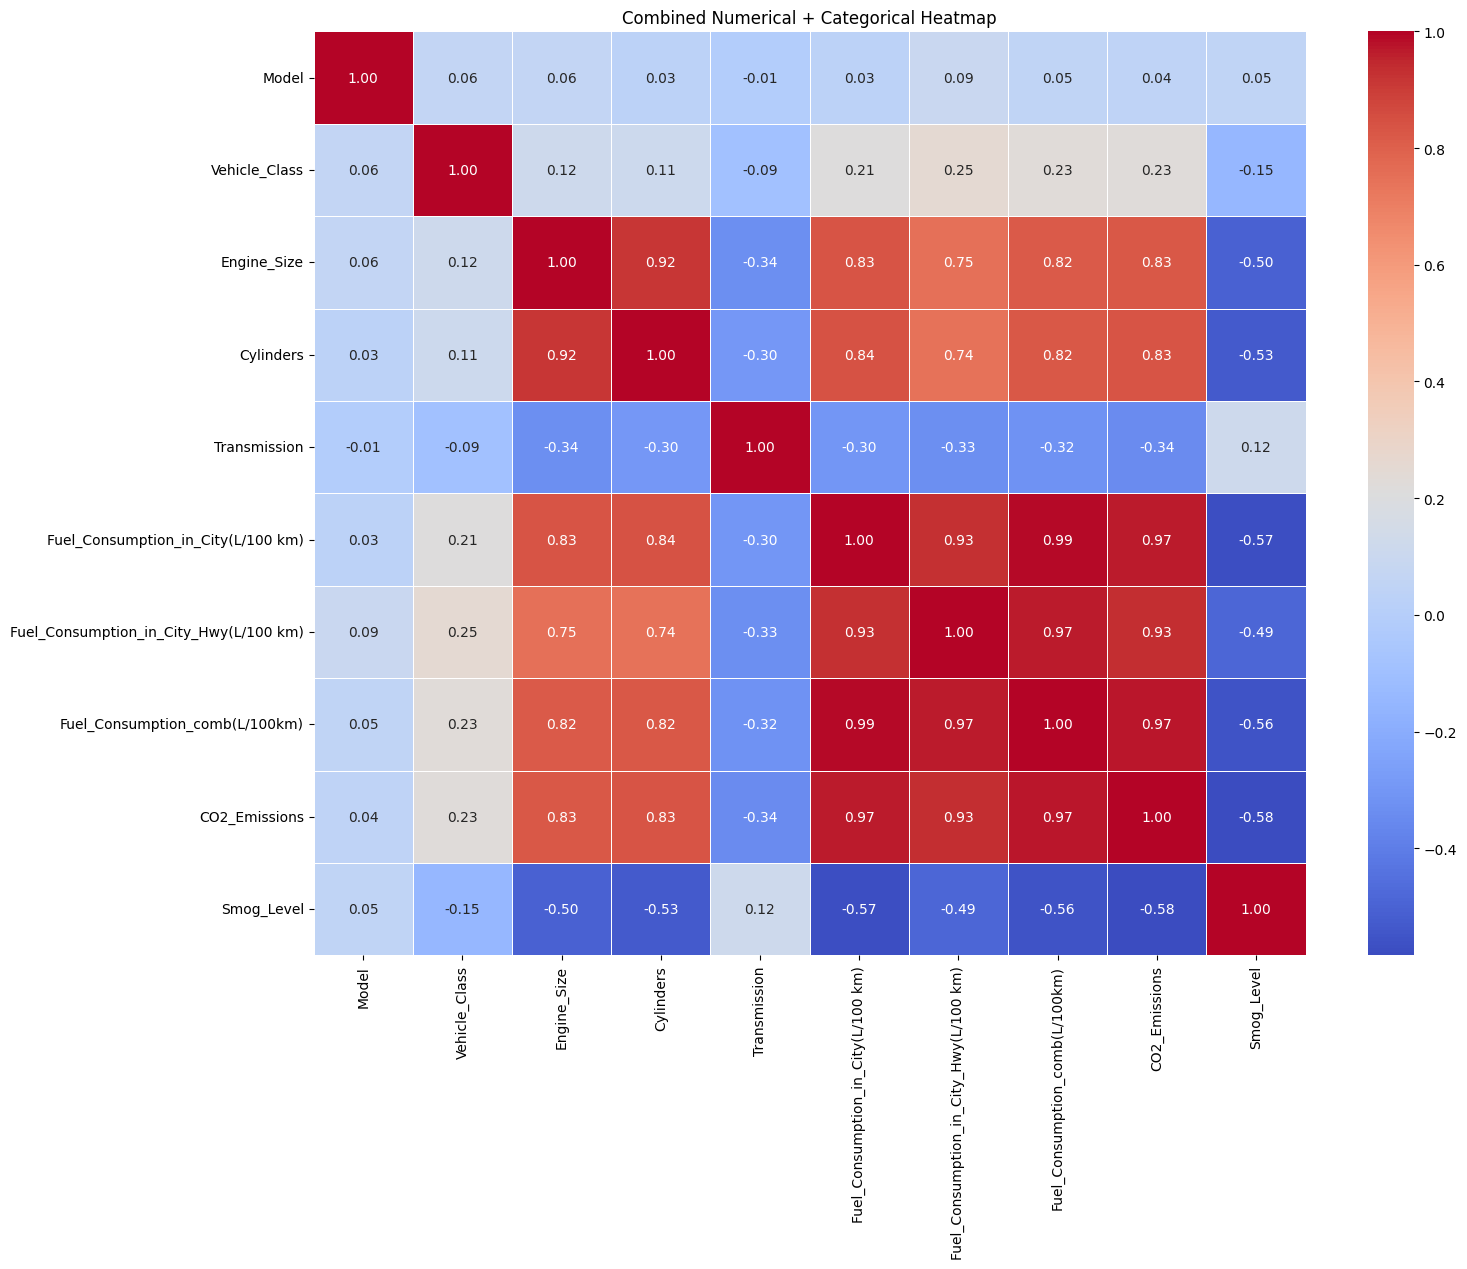

In [3]:
chdf = df.drop('Make', axis=1)
chdf = chdf.drop('Model_Year',axis=1)
le = LabelEncoder()

for col in chdf.select_dtypes(include='object').columns:
    chdf[col] = le.fit_transform(
        chdf[col].astype(str)
    )

corr = chdf.corr()

plt.figure(figsize=(16,12))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)
plt.title("Combined Numerical + Categorical Heatmap")
plt.show()

In [4]:
#lets try to predict CO2 emissions
chdfd = df.drop(columns=['Model_Year','Make','Model','Vehicle_Class','Transmission','CO2_Emissions'])
chdfd.describe()

,Engine_Size,Cylinders,Fuel_Consumption_in_City(L/100 km),Fuel_Consumption_in_City_Hwy(L/100 km),Fuel_Consumption_comb(L/100km),Smog_Level
count,935.000000,935.000000,935.000000,935.000000,935.000000,935.000000
mean,3.214866,5.716578,12.498610,9.306203,11.060214,4.726203
std,1.388513,1.977359,3.487271,2.215819,2.867028,1.712127
min,1.000000,3.000000,4.000000,3.900000,4.000000,1.000000
25%,2.000000,4.000000,10.100000,7.700000,9.100000,3.000000
50%,3.000000,6.000000,12.000000,9.000000,10.700000,5.000000
75%,4.000000,8.000000,14.800000,10.800000,13.100000,6.000000
max,8.000000,16.000000,30.300000,20.900000,26.100000,7.000000


In [5]:
# testing directly
qy = df.iloc[:,10]
print(qy)
txain,tx,tyain,ty = train_test_split(chdfd,qy,test_size=0.2)

0      199
1      256
2      232
3      242
4      230
      ... 
930    219
931    230
932    240
933    236
934    245
Name: CO2_Emissions, Length: 935, dtype: int64


In [6]:
tlr = LinearRegression()
tlr.fit(txain,tyain)
tpred = tlr.predict(tx)
print(r2_score(ty,tpred))

0.9722144884207995


Index(['Engine_Size', 'Cylinders', 'Fuel_Consumption_in_City(L/100 km)',
       'Fuel_Consumption_in_City_Hwy(L/100 km)',
       'Fuel_Consumption_comb(L/100km)', 'Smog_Level'],
      dtype='object')


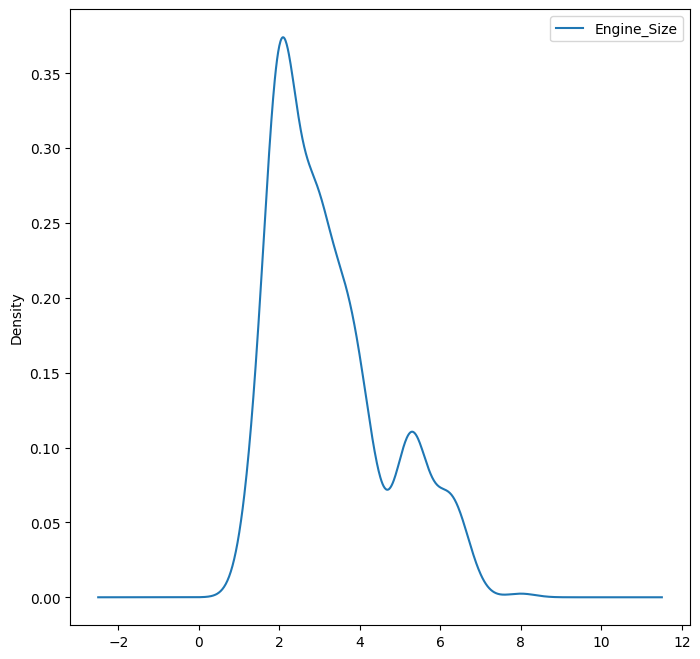

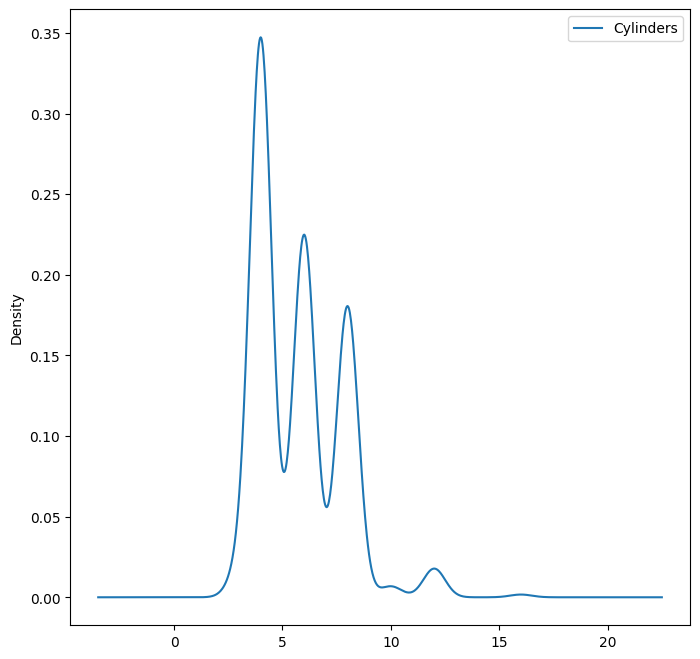

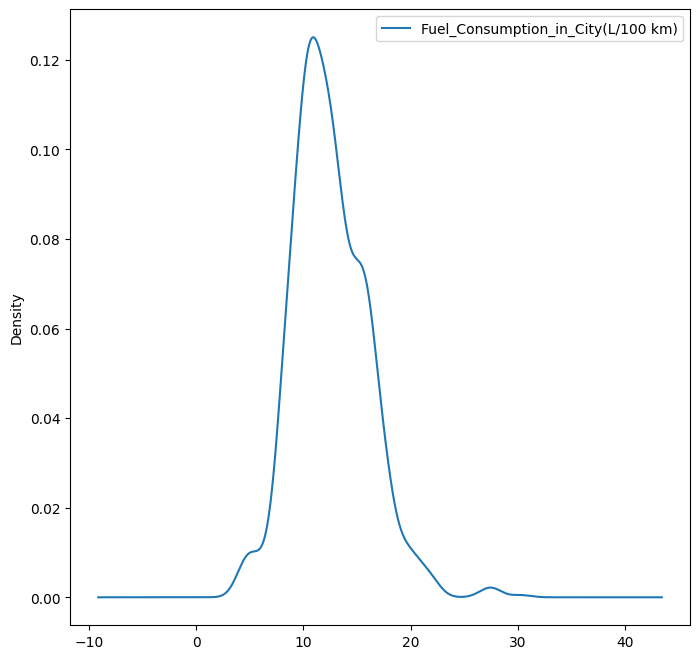

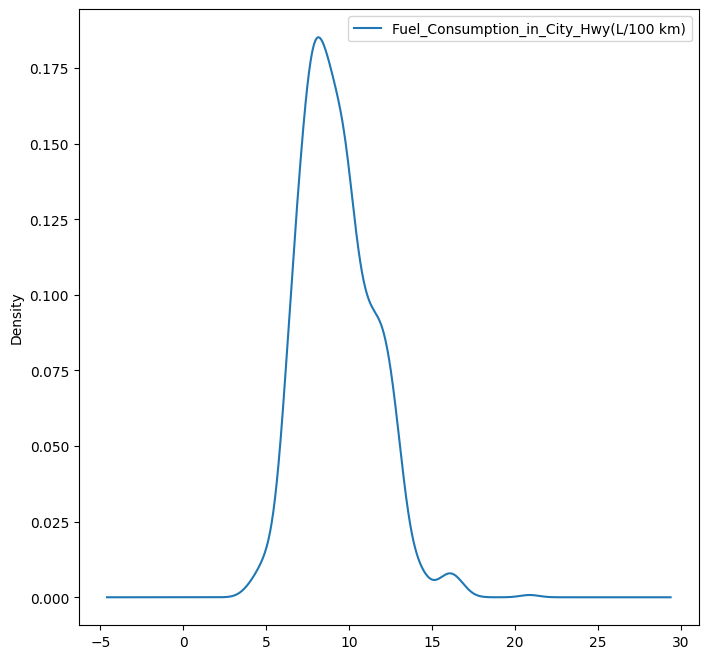

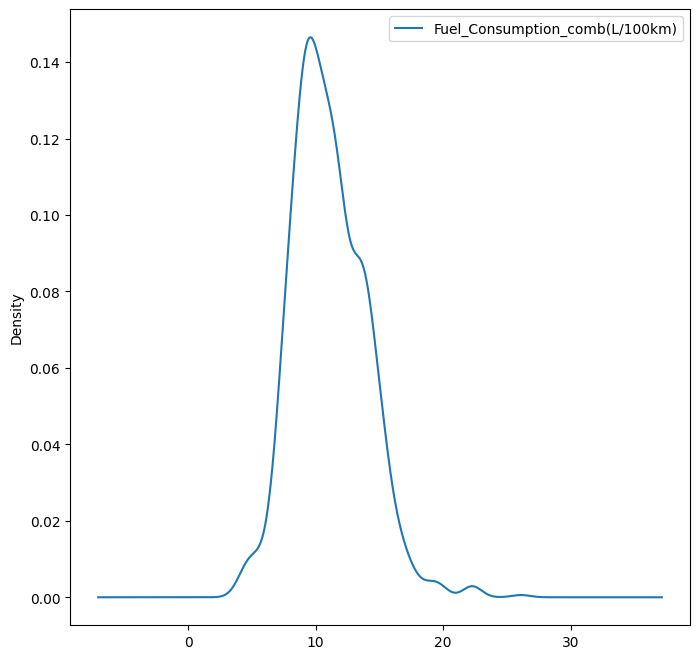

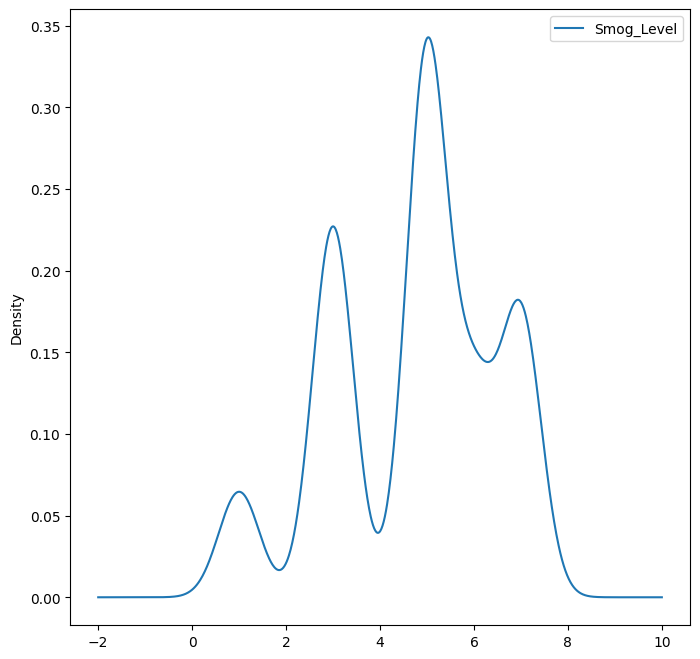

In [7]:
# custom function for printing all numeric columns plot
def plotkde(a):
    df.plot(y=[a], kind='kde',figsize=(8,8))
allnc = chdfd.columns
print(allnc)
for i in allnc:
    plotkde(i)

[[-0.470758   -0.95872204 -0.71915803 -1.08774888 -0.85169781 -1.05217147]
 [ 0.46047356  0.42332974 -0.33350763  0.74479336  0.06810004 -1.05217147]
 [-0.94148275 -0.95872204 -0.36464856 -0.2266219  -0.33431594  0.73848759]
 ...
 [-0.94148275 -0.95872204 -0.15015955 -0.2266219  -0.18456702  1.43817554]
 [-0.94148275 -0.95872204 -0.21062425 -0.32592675 -0.25893051  0.08741418]
 [-0.94148275 -0.95872204 -0.03109997 -0.27600865 -0.11119389  1.43817554]]


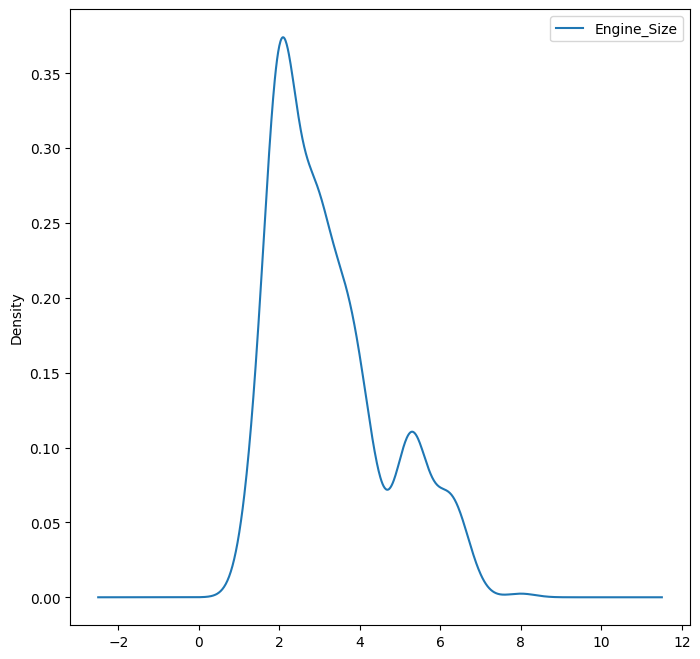

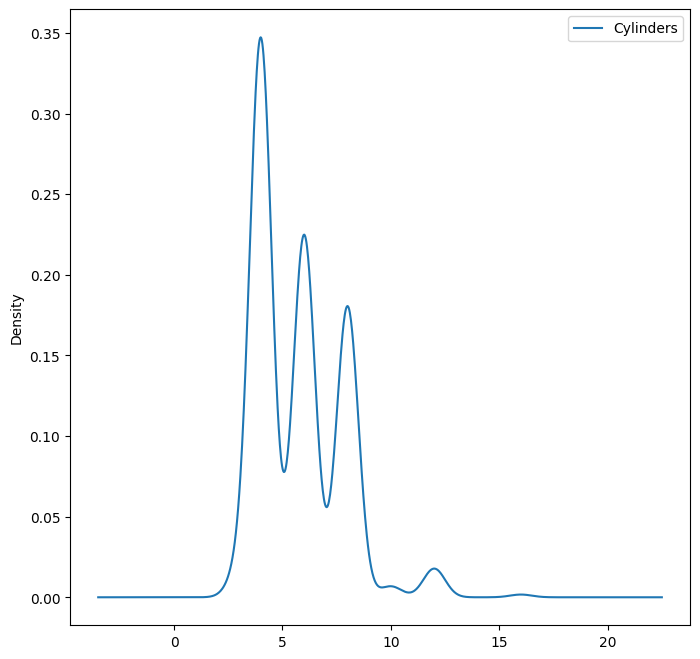

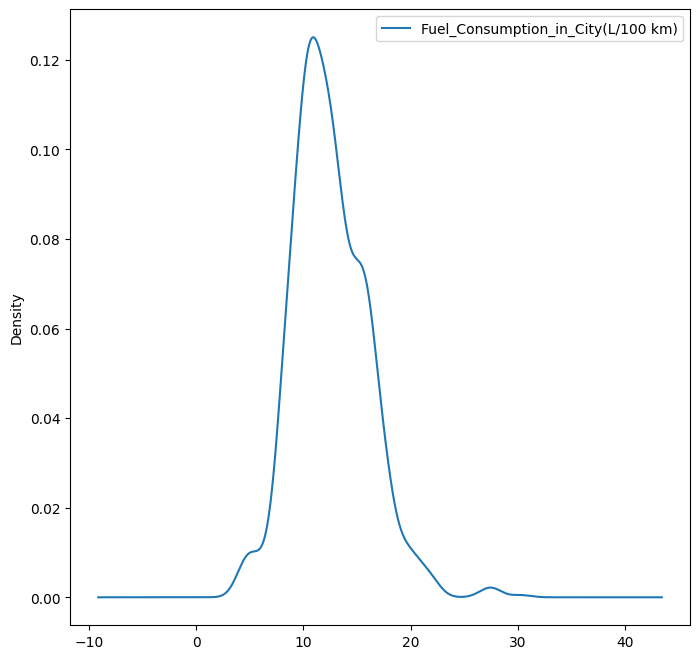

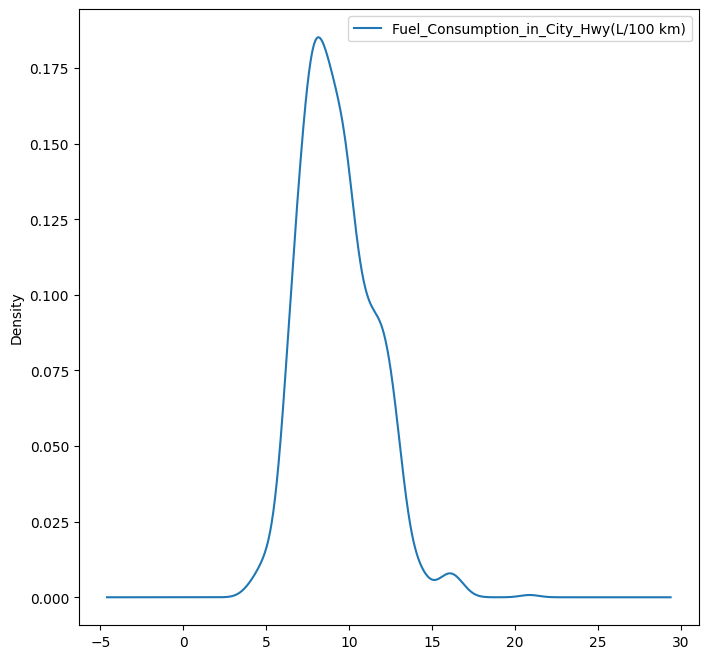

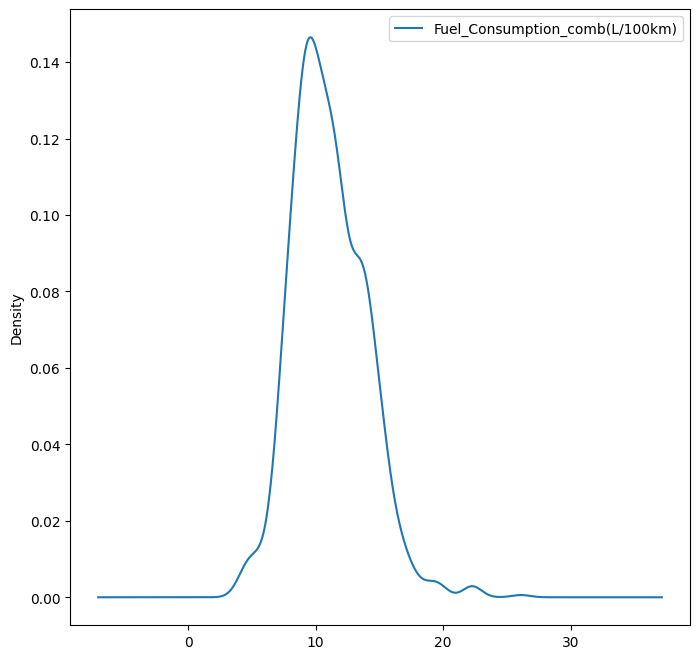

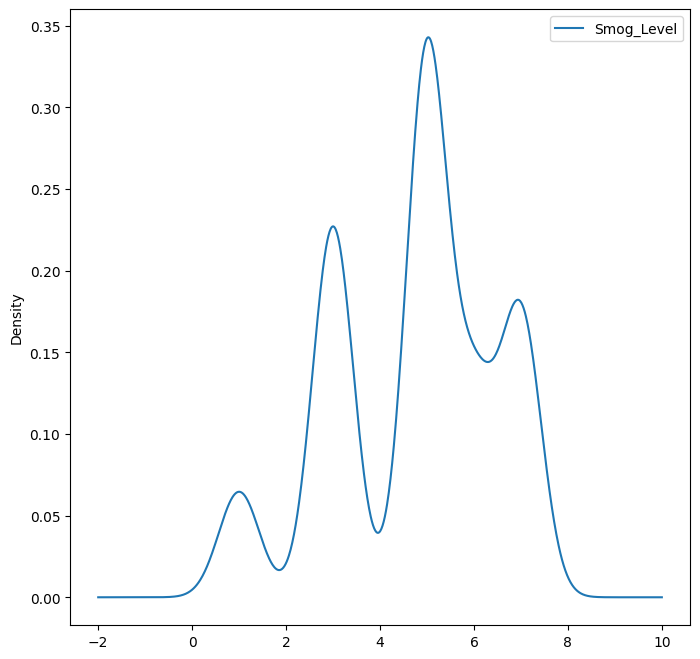

In [8]:
# after yeo-johnson
pt = PowerTransformer(method='yeo-johnson', standardize=True)
transformed = pt.fit_transform(chdfd)
print(transformed)
transformed= pd.DataFrame(transformed, columns=['Engine_Size', 'Cylinders',
                                                'Fuel_Consumption_in_City(L/100 km)','Fuel_Consumption_in_City_Hwy(L/100 km)',
                                                'Fuel_Consumption_comb(L/100km)', 'Smog_Level'])
for i in transformed:
    plotkde(i)

In [9]:
# Yeo-Johnson completed ts work and now all the numerical columns are scaled and has their best possible lamda values
print('\n',pt.lambdas_)


 [-0.61663159 -0.96398148  0.33637226 -0.01659107  0.2425436   1.50279617]


In [10]:
# check for distinct values
def duplicates(column_name):
    counts = df[column_name].value_counts()
    duplicates = counts[counts > 1]
    result = duplicates.reset_index()
    result.columns = [column_name, 'Count']
    a = result
    print(a)
duplicates('Make')
duplicates('Model')
duplicates('Vehicle_Class')
duplicates('Transmission')
print('''As we can see from above there are many categories
so we cannot use label encoding as we are using linear regression 
one hot encoding cannot be useed because there are too many columns
so the best option remains is .Target Encoding.''')

             Make  Count
0            Ford     87
1       Chevrolet     84
2   Mercedes-Benz     72
3         Porsche     63
4             GMC     61
5             BMW     54
6          Toyota     49
7            Audi     43
8            Jeep     36
9           Mazda     29
10        Hyundai     27
11          Lexus     27
12            Kia     25
13          Honda     23
14           MINI     22
15         Nissan     22
16          Dodge     22
17       Cadillac     22
18            Ram     16
19     Volkswagen     16
20         Subaru     16
21          Volvo     13
22       Maserati     11
23    Rolls-Royce     10
24    Lamborghini      9
25          Buick      9
26        Bentley      8
27        Genesis      8
28        Lincoln      7
29          Acura      6
30     Alfa Romeo      6
31       Infiniti      6
32       Chrysler      6
33   Aston Martin      6
34         Jaguar      6
35     Mitsubishi      5
36        Bugatti      2
                                  Model  Count
0  

In [13]:
# now we will encode the categorical columns
# as we need column transformer for the target encoding lets build a pipeline
dt = df

x= pd.DataFrame(dt, columns=['Make', 'Model', 'Vehicle_Class', 'Engine_Size',
       'Cylinders', 'Transmission', 'Fuel_Consumption_in_City(L/100 km)',
       'Fuel_Consumption_in_City_Hwy(L/100 km)',
       'Fuel_Consumption_comb(L/100km)', 'Smog_Level'])


#yeo-johnson
yeo = PowerTransformer(method='yeo-johnson',standardize = True)

trf1 = ColumnTransformer([('yeo-done',yeo,['Engine_Size', 'Cylinders','Fuel_Consumption_in_City(L/100 km)',
                                           'Fuel_Consumption_in_City_Hwy(L/100 km)',
                                           'Fuel_Consumption_comb(L/100km)', 
                                           'Smog_Level'])],remainder='passthrough',verbose_feature_names_out=False)


#Vehicle class seems important so lets one hot encode it
ohe = OneHotEncoder(drop='first',sparse_output='False')


pipe = Pipeline([
    ('yeo',trf1)
])

pipe.set_output(transform='pandas')
print(pipe.fit_transform(x))
print(pipe.named_steps['yeo'].get_feature_names_out())


     Engine_Size  Cylinders  Fuel_Consumption_in_City(L/100 km)  \
0      -0.470758  -0.958722                           -0.719158   
1       0.460474   0.423330                           -0.333508   
2      -0.941483  -0.958722                           -0.364649   
3      -0.941483  -0.958722                           -0.271734   
4      -0.941483  -0.958722                           -0.302537   
..           ...        ...                                 ...   
930    -0.941483  -0.958722                           -0.459117   
931    -0.941483  -0.958722                           -0.333508   
932    -0.941483  -0.958722                           -0.150160   
933    -0.941483  -0.958722                           -0.210624   
934    -0.941483  -0.958722                           -0.031100   

     Fuel_Consumption_in_City_Hwy(L/100 km)  Fuel_Consumption_comb(L/100km)  \
0                                 -1.087749                       -0.851698   
1                                  0.